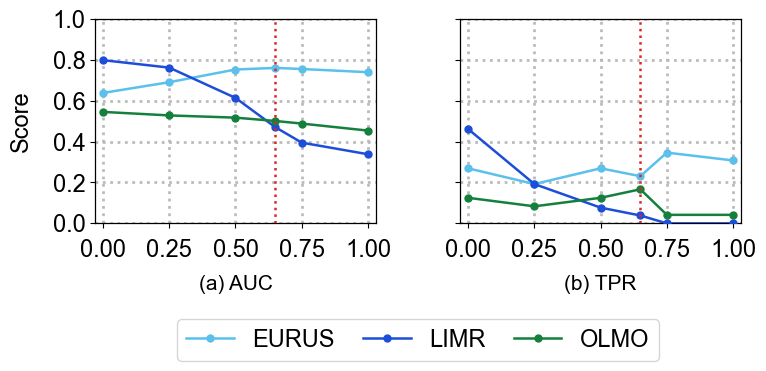

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.lines import Line2D

_ARIAL = Path("final_results/fonts/Arial.ttf")
if _ARIAL.is_file():
    fm.fontManager.addfont(str(_ARIAL))


def use_arial_font(**extra):
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
            "mathtext.default": "regular",
            "axes.unicode_minus": False,
            **extra,
        }
    )

# -----------------------------
# Beta sweep (default_robust) — three models, mix scores only
# mix(β) = β·rank_pct(self_critique) + (1−β)·rank_pct(rep_stiff_lara_robust)
# -----------------------------
VARIANT = "default_robust"
PLOT_BETAS = [0.0, 0.25, 0.5, 0.65, 0.75, 1.0]  # includes default mix β
X_AXIS_TICKS = [0.0, 0.25, 0.5, 0.75, 1.0]       # 0.65 marked by vertical line only
DEFAULT_MIX_BETA = 0.65
DEFAULT_MIX_LINE_KW = dict(color="#DC2626", linestyle=":", linewidth=1.8, zorder=4)

MODELS = [
    (
        "EURUS",
        Path(
            "final_results/Eurus-2-7B-PRIME_eurus/eurus_member/_all__all_samples/"
            "blank_k_sweep/k1/lara_self_critique_beta_sweep.json"
        ),
    ),
    (
        "LIMR",
        Path(
            "final_results/GAIR__LIMR/limr/_all__all_samples/"
            "blank_k_sweep/k1/lara_self_critique_beta_sweep.json"
        ),
    ),
    (
        "OLMO",
        Path(
            "final_results/Olmo-3.1-7B-RL-Zero-Math_olmoe/olmoe_member/_all__all_samples/"
            "blank_k_sweep/k1/lara_self_critique_beta_sweep.json"
        ),
    ),
]

# light blue, blue, green
MODEL_COLORS = ["#5BC0EB", "#1D4ED8", "#15803D"]


def load_beta_sweep(path: Path, variant: str) -> pd.DataFrame:
    with open(path) as f:
        data = json.load(f)
    rows = []
    for point in data["variants"][variant]["sweep"]:
        rows.append(
            {
                "beta": point["beta"],
                "auc": point["metrics"]["roc_auc"],
                "tpr": point["metrics"]["tpr_at_fpr_5"],
            }
        )
    df = pd.DataFrame(rows).sort_values("beta").reset_index(drop=True)
    mask = df["beta"].apply(lambda b: any(abs(b - t) < 1e-6 for t in PLOT_BETAS))
    return df.loc[mask].reset_index(drop=True)


sweeps = {name: load_beta_sweep(path, VARIANT) for name, path in MODELS}

use_arial_font(
    **{
        "axes.labelsize": 17,
        "axes.titlesize": 17,
        "xtick.labelsize": 17,
        "ytick.labelsize": 17,
        "legend.fontsize": 17,
        "axes.linewidth": 2,
        "grid.linewidth": 2,
    }
)

PANEL_TAGS = ["(a) AUC", "(b) TPR"]
METRIC_COLS = ["auc", "tpr"]
LEGEND_KW = dict(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
    borderpad=0.45,
    labelspacing=0.4,
    handlelength=1.8,
    handletextpad=0.5,
)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.65), sharey=True)

for ax, panel_tag, metric_col in zip(axes, PANEL_TAGS, METRIC_COLS):
    for (name, _), color in zip(MODELS, MODEL_COLORS):
        df = sweeps[name]
        ax.plot(
            df["beta"].values,
            df[metric_col].values,
            color=color,
            linestyle="-",
            marker="o",
            markersize=5.0,
            markerfacecolor=color,
            markeredgecolor=color,
            linewidth=1.8,
            label=name,
            zorder=3,
        )

    ax.axvline(DEFAULT_MIX_BETA, **DEFAULT_MIX_LINE_KW)

    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(0, 1)
    ax.set_xticks(X_AXIS_TICKS)
    ax.set_xticklabels([f"{b:.2f}" for b in X_AXIS_TICKS])
    ax.tick_params(axis="x", pad=8)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.grid(True, linestyle=":", color="0.72", alpha=0.95)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color("black")

axes[0].set_ylabel("Score", labelpad=14)

legend_handles = [
    Line2D(
        [0], [0], color=color, linestyle="-", marker="o",
        markersize=5.0, markerfacecolor=color, markeredgecolor=color,
        linewidth=1.8, label=name,
    )
    for (name, _), color in zip(MODELS, MODEL_COLORS)
]

plt.subplots_adjust(left=0.14, right=0.99, top=0.96, bottom=0.40, wspace=0.30)

pos0, pos1 = axes[0].get_position(), axes[1].get_position()
center_x = (pos0.x0 + pos1.x1) / 2
tag_y = pos0.y0 - 0.14
legend_y = tag_y - 0.09

for ax, tag in zip(axes, PANEL_TAGS):
    bb = ax.get_position()
    cx = bb.x0 + bb.width / 2
    fig.text(cx, tag_y, tag, ha="center", va="top", fontsize=15, fontname="Arial")

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(center_x, legend_y),
    bbox_transform=fig.transFigure,
    ncol=3,
    columnspacing=1.2,
    prop={"family": "Arial", "size": 17},
)
plt.show()


/tmp/ipykernel_440467/169098756.py:129: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.vstack(z_parts), axis=0)


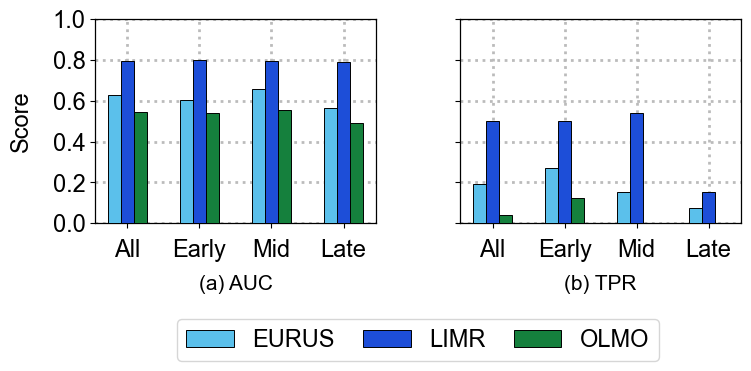

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.patches import Patch

_ARIAL = Path("final_results/fonts/Arial.ttf")
if _ARIAL.is_file():
    fm.fontManager.addfont(str(_ARIAL))


def use_arial_font(**extra):
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
            "mathtext.default": "regular",
            "axes.unicode_minus": False,
            **extra,
        }
    )


# -----------------------------
# S_LaRA layer-window scores: all layers vs early / mid / late layers
# -----------------------------

MODELS_LW = ["EURUS", "LIMR", "OLMO"]
MODEL_COLORS_LW = ["#5BC0EB", "#1D4ED8", "#15803D"]
METRICS_LW = ["All", "Early", "Mid", "Late"]
METRIC_X = np.arange(len(METRICS_LW))

SCORE_PATHS = {
    "EURUS": Path(
        "final_results/Eurus-2-7B-PRIME_eurus/eurus_member/_all__all_samples/"
        "blank_k_sweep/k1/rep_stiff_scores.json"
    ),
    "LIMR": Path(
        "final_results/GAIR__LIMR/limr/_all__all_samples/"
        "blank_k_sweep/k1/rep_stiff_scores.json"
    ),
    "OLMO": Path(
        "final_results/Olmo-3.1-7B-RL-Zero-Math_olmoe/olmoe_member/_all__all_samples/"
        "blank_k_sweep/k1/rep_stiff_scores.json"
    ),
}


def _roc_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    """Mann-Whitney AUC implementation; higher scores indicate member-likeness."""
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    pos = s[y == 1]
    neg = s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    wins = (pos[:, None] > neg[None, :]).mean()
    ties = (pos[:, None] == neg[None, :]).mean()
    return float(wins + 0.5 * ties)


def _tpr_at_fpr_5(y_true: np.ndarray, scores: np.ndarray) -> float:
    """Maximum empirical TPR among thresholds whose FPR is at most 5%."""
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if np.sum(y == 1) == 0 or np.sum(y == 0) == 0:
        return float("nan")
    thresholds = np.r_[np.inf, np.sort(np.unique(s))[::-1]]
    best = 0.0
    for threshold in thresholds:
        pred = s >= threshold
        fpr = np.mean(pred[y == 0])
        if fpr <= 0.05:
            best = max(best, float(np.mean(pred[y == 1])))
    return best


def _infer_layer_ids(rows: list[dict]) -> list[int]:
    layer_ids = []
    for key in rows[0]:
        if key.startswith("rsm_L"):
            layer_ids.append(int(key.removeprefix("rsm_L")))
    return sorted(layer_ids)


def _segment_layer_ids(layer_ids: list[int]) -> dict[str, list[int]]:
    n_layers = len(layer_ids)
    n_early = (9 * n_layers) // 28
    n_mid = (9 * n_layers) // 28
    early = layer_ids[:n_early]
    mid = layer_ids[n_early : n_early + n_mid]
    late = layer_ids[n_early + n_mid :]
    return {"All": layer_ids, "Early": early, "Mid": mid, "Late": late}


def _lara_robust_window(rows: list[dict], layer_ids: list[int]) -> np.ndarray:
    labels = np.array([int(row["ground_truth_label"]) for row in rows])
    clean_mask = labels == 0
    metrics = [
        ("rsm", "signed"),
        ("directional_collapse", "absolute"),
        ("rsi", "negated"),
    ]
    z_parts = []

    for metric, alignment in metrics:
        for layer_id in layer_ids:
            vals = np.array([float(row[f"{metric}_L{layer_id}"]) for row in rows], dtype=float)
            vals = np.sign(vals) * np.log1p(np.abs(vals))
            clean_vals = vals[clean_mask]
            clean_vals = clean_vals[np.isfinite(clean_vals)]
            if clean_vals.size < 2:
                continue
            med = float(np.median(clean_vals))
            mad = float(np.median(np.abs(clean_vals - med)))
            z = (vals - med) / (1.4826 * mad + 1e-8)
            if alignment == "absolute":
                z_aligned = np.abs(z)
            elif alignment == "negated":
                z_aligned = -z
            else:
                z_aligned = z
            z_parts.append(np.abs(z_aligned))

    return np.nanmean(np.vstack(z_parts), axis=0)


def load_layer_window_table(score_path: Path) -> dict[str, tuple[float, float]]:
    rows = json.loads(score_path.read_text())
    labels = np.array([int(row["ground_truth_label"]) for row in rows])
    windows = _segment_layer_ids(_infer_layer_ids(rows))
    out = {}
    for label, layer_ids in windows.items():
        scores = _lara_robust_window(rows, layer_ids)
        out[label] = (_roc_auc(labels, scores), _tpr_at_fpr_5(labels, scores))
    return out


TABLE = {model: load_layer_window_table(SCORE_PATHS[model]) for model in MODELS_LW}

BAR_WIDTH = 0.18
BAR_KW = dict(edgecolor="black", linewidth=0.7)

PANEL_TAGS_LW = ["(a) AUC", "(b) TPR"]
LEGEND_KW_LW = dict(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
    borderpad=0.55,
    labelspacing=0.45,
    handlelength=2.2,
    handletextpad=0.65,
    fontsize=15,
)

use_arial_font(
    **{
        "axes.labelsize": 17,
        "axes.titlesize": 17,
        "xtick.labelsize": 17,
        "ytick.labelsize": 17,
        "legend.fontsize": 17,
        "axes.linewidth": 2,
        "grid.linewidth": 2,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.65), sharey=True)
legend_handles = []

n_models = len(MODELS_LW)
offsets = (np.arange(n_models) - (n_models - 1) / 2) * BAR_WIDTH

for ax, panel_tag, value_idx in zip(axes, PANEL_TAGS_LW, [0, 1]):
    for i, (model, color) in enumerate(zip(MODELS_LW, MODEL_COLORS_LW)):
        y = [TABLE[model][metric][value_idx] for metric in METRICS_LW]
        ax.bar(
            METRIC_X + offsets[i],
            y,
            width=BAR_WIDTH,
            color=color,
            label=model,
            zorder=3,
            **BAR_KW,
        )
        if value_idx == 0:
            legend_handles.append(Patch(facecolor=color, label=model, **BAR_KW))

    ax.set_xlim(-0.45, len(METRICS_LW) - 0.55)
    ax.set_ylim(0, 1)
    ax.set_xticks(METRIC_X)
    ax.set_xticklabels(METRICS_LW, rotation=0, ha="center")
    ax.tick_params(axis="x", pad=8)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.grid(True, linestyle=":", color="0.72", alpha=0.95)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color("black")

axes[0].set_ylabel("Score", labelpad=14)

plt.subplots_adjust(left=0.14, right=0.99, top=0.96, bottom=0.40, wspace=0.30)

pos0, pos1 = axes[0].get_position(), axes[1].get_position()
center_x = (pos0.x0 + pos1.x1) / 2
tag_y = pos0.y0 - 0.14
legend_y = tag_y - 0.09

for ax, tag in zip(axes, PANEL_TAGS_LW):
    bb = ax.get_position()
    cx = bb.x0 + bb.width / 2
    fig.text(cx, tag_y, tag, ha="center", va="top", fontsize=15, fontname="Arial")

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(center_x, legend_y),
    bbox_transform=fig.transFigure,
    ncol=3,
    columnspacing=1.2,
    prop={"family": "Arial", "size": 17},
)
plt.show()

Metric                 AUC  TPR@FPR=5%
Perturbation                          
Distractor Insert.  0.6897      0.0000
Info Rem.           0.5609      0.1154
Num Replace.        0.6667      0.1724
Var Rename          0.6473      0.0909


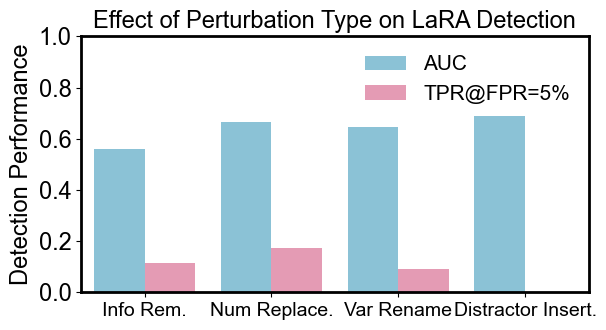

In [3]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

use_arial_font()

EURUS_PERTURBATION_BASE = Path(
    "final_results/Eurus-2-7B-PRIME_eurus/eurus_member/_all__all_samples/perturbation_type"
)
PERTURBATION_TYPES = [
    ("info_rem", "Info Rem."),
    ("num_replace", "Num Replace."),
    ("var_rename", "Var Rename"),
    ("distractor_insert", "Distractor Insert."),
]
LARA_ROBUST_KEY = "rep_stiff_lara_robust"


def load_lara_robust_metrics(summary_path: Path) -> tuple[float, float]:
    summary = json.loads(summary_path.read_text())
    perf = summary[LARA_ROBUST_KEY]["overall_performance"]
    return float(perf["roc_auc"]), float(perf["tpr_at_fpr_5"])


rows = []
for slug, label in PERTURBATION_TYPES:
    summary_path = EURUS_PERTURBATION_BASE / slug / "k1" / "evaluation_summary.json"
    auc, tpr = load_lara_robust_metrics(summary_path)
    rows.append({"Perturbation": label, "Metric": "AUC", "Score": auc})
    rows.append({"Perturbation": label, "Metric": "TPR@FPR=5%", "Score": tpr})

df = pd.DataFrame(rows)
print(df.pivot(index="Perturbation", columns="Metric", values="Score").round(4))

METRIC_COLORS = ["#7EC8E3", "#F08FB0"]  # light blue, light pink (slightly darker)

plt.figure(figsize=(6.2, 3.4))
sns.barplot(
    data=df,
    x="Perturbation",
    y="Score",
    hue="Metric",
    palette=METRIC_COLORS,
)

plt.ylabel("Detection Performance")
plt.xlabel("")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.title("Effect of Perturbation Type on LaRA Detection")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Pooled samples: 244
model
Eurus     48
LIMR     126
OLMoE     70
dtype: int64


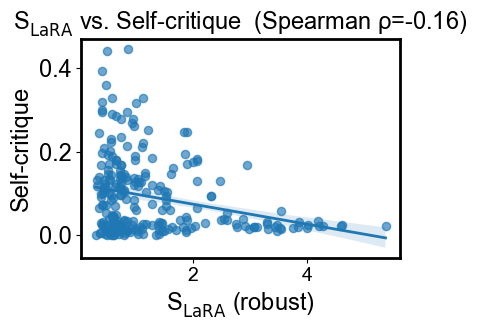

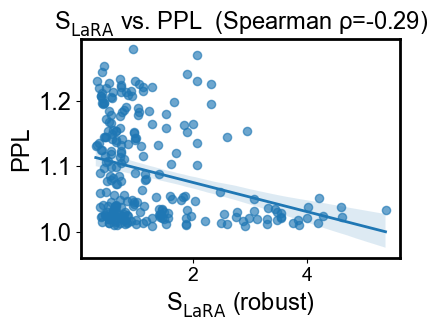

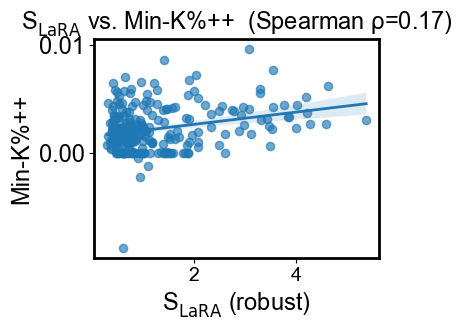

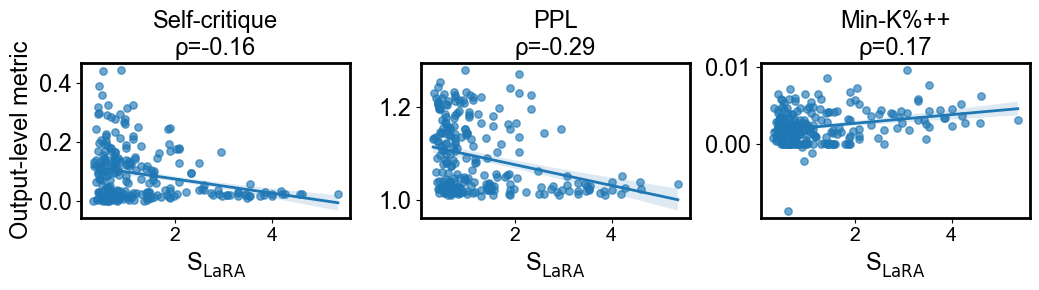

In [4]:
import json
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

use_arial_font()

ROOT = Path("/scratch2/mjgwak/rl-data-contamination-mj")
sys.path.insert(0, str(ROOT))

from detectors.self_critique import SelfCritiqueDetector
from detectors.ppl import PPLDetector
from detectors.mink import MinkDetector

MINK_RATIO = 0.2  # matches evaluate_all_methods default

RUNS = [
    ("Eurus", "Eurus-2-7B-PRIME_eurus/eurus_member/_all__all_samples"),
    ("LIMR", "GAIR__LIMR/limr/_all__all_samples"),
    ("OLMoE", "Olmo-3.1-7B-RL-Zero-Math_olmoe/olmoe_member/_all__all_samples"),
]

sc_det = SelfCritiqueDetector()
ppl_det = PPLDetector()
mink_pp_det = MinkDetector(mink_ratio=MINK_RATIO, use_plus_plus=True)

def load_run(model_label: str, rel_path: str) -> pd.DataFrame:
    base = ROOT / "final_results" / rel_path
    gen_path = base / "generated_data.jsonl"
    rs_path = base / "blank_k_sweep/k1/rep_stiff_scores.json"

    with open(rs_path, encoding="utf-8") as f:
        rep_stiff = json.load(f)
    lara_by_prompt = {
        r["original_user_content"]: r.get("lara_robust")
        for r in rep_stiff
    }

    rows = []
    with open(gen_path, encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            prompt = item["original_user_content"]
            rows.append({
                "model": model_label,
                "ground_truth_label": item["ground_truth_label"],
                "S_LaRA": lara_by_prompt.get(prompt),
                "Self-critique": sc_det.calculate_score(item),
                "PPL": ppl_det.calculate_score(item),
                "Min-K%++": mink_pp_det.calculate_score(item),
            })
    return pd.DataFrame(rows)

df = pd.concat([load_run(label, path) for label, path in RUNS], ignore_index=True)
df = df.dropna(subset=["S_LaRA", "Self-critique", "PPL", "Min-K%++"])
print(f"Pooled samples: {len(df)}")
print(df.groupby("model").size())

metrics = ["Self-critique", "PPL", "Min-K%++"]

# Individual plots (pooled across three models)
for metric in metrics:
    plt.figure(figsize=(4.2, 3.4))
    sns.regplot(
        data=df,
        x="S_LaRA",
        y=metric,
        scatter_kws={"s": 35, "alpha": 0.65},
        line_kws={"linewidth": 2},
    )
    rho = df["S_LaRA"].corr(df[metric], method="spearman")
    plt.title(f"$S_{{\\mathrm{{LaRA}}}}$ vs. {metric}  (Spearman ρ={rho:.2f})")
    plt.xlabel(r"$S_{\mathrm{LaRA}}$ (robust)")
    plt.ylabel(metric)
    plt.tight_layout()
    safe = metric.replace("%", "").replace("+", "pp").replace("-", "_")
    plt.savefig(f"slara_robust_vs_{safe}.pdf", bbox_inches="tight")
    plt.show()

# Combined 1×3 panel — independent y scales, one y-axis label on the left only
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0))  # no sharey

for ax, metric in zip(axes, metrics):
    sns.regplot(
        data=df,
        x="S_LaRA",
        y=metric,
        ax=ax,
        scatter_kws={"s": 28, "alpha": 0.65},
        line_kws={"linewidth": 2},
    )
    rho = df["S_LaRA"].corr(df[metric], method="spearman")
    ax.set_title(f"{metric}\nρ={rho:.2f}")
    ax.set_xlabel(r"$S_{\mathrm{LaRA}}$", fontsize = 17)
    ax.set_ylabel("")  # clear any default label; no "PPL" / "Min-K%++" on the side

axes[0].set_ylabel("Output-level metric")
# Keep y tick numbers on all three panels (do not use labelleft=False)

plt.tight_layout()
plt.savefig("slara_robust_output_metric_correlation.pdf", bbox_inches="tight")
plt.show()

Metric         AUC  TPR@FPR=5%
Num Blanks                    
1           0.6189      0.1154
2           0.7348      0.1111
3           0.7709      0.0400
4           0.6917      0.3158


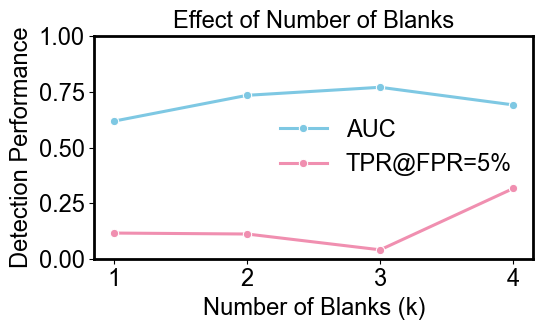

In [5]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

use_arial_font()

# EURUS member blank-k sweep (run patch_lara_component_evaluation_summary.py first)
EURUS_BLANK_K_BASE = Path(
    "final_results_sweeps/Eurus-2-7B-PRIME_eurus/eurus_member/_all__all_samples/blank_k_sweep"
)
BLANK_K_VALUES = [1, 2, 3, 4]
LARA_ROBUST_KEY = "rep_stiff_lara_robust"


def load_lara_robust_metrics(summary_path: Path) -> tuple[float, float]:
    summary = json.loads(summary_path.read_text())
    perf = summary[LARA_ROBUST_KEY]["overall_performance"]
    return float(perf["roc_auc"]), float(perf["tpr_at_fpr_5"])


rows = []
for k in BLANK_K_VALUES:
    summary_path = EURUS_BLANK_K_BASE / f"k{k}" / "evaluation_summary.json"
    auc, tpr = load_lara_robust_metrics(summary_path)
    rows.append({"Num Blanks": k, "Metric": "AUC", "Score": auc})
    rows.append({"Num Blanks": k, "Metric": "TPR@FPR=5%", "Score": tpr})

df = pd.DataFrame(rows)
print(df.pivot(index="Num Blanks", columns="Metric", values="Score").round(4))

METRIC_COLORS = ["#7EC8E3", "#F08FB0"]  # light blue, light pink

plt.figure(figsize=(5.4, 3.4))
sns.lineplot(
    data=df,
    x="Num Blanks",
    y="Score",
    hue="Metric",
    marker="o",
    linewidth=2.2,
    palette=METRIC_COLORS,
)

ax = plt.gca()
plt.xticks(BLANK_K_VALUES)
plt.ylim(0, 1.0)
ax.set_title("Effect of Number of Blanks")
plot_fs = ax.title.get_fontsize()
ax.set_xlabel("Number of Blanks (k)", fontsize=plot_fs)
ax.set_ylabel("Detection Performance", fontsize=plot_fs)
ax.tick_params(axis="both", labelsize=plot_fs)
ax.legend(frameon=False, fontsize=plot_fs)
plt.tight_layout()
plt.show()

LIMR S_LaRA AUC: [0.795, 0.7240477968633308, 0.8101960784313725] TPR: [0.46153846153846156, 0.23076923076923078, 0.2]
LIMR SC AUC: [0.44384615384615383, 0.39717948717948715, 0.45769230769230773] TPR: [0.0, 0.0, 0.0]
LIMR SC+S_LaRA AUC: [0.46807692307692306, 0.4581777445855116, 0.5360784313725491] TPR: [0.038461538461538464, 0.038461538461538464, 0.04]


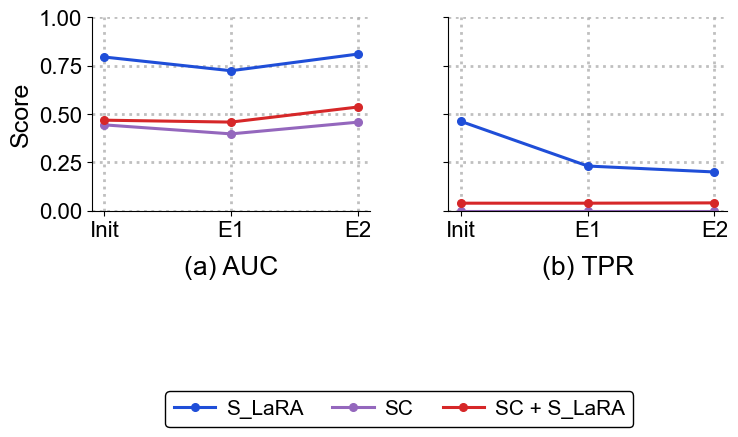

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager as fm

# -----------------------------
# Global Font Settings
# -----------------------------
_ARIAL = Path("final_results/fonts/Arial.ttf")
if _ARIAL.is_file():
    fm.fontManager.addfont(str(_ARIAL))

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
        "mathtext.default": "regular",
        "axes.unicode_minus": False,
        "font.size": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# -----------------------------
# X-axis
# -----------------------------
x = np.arange(3)
x_labels = ["Init", "E1", "E2"]

# -----------------------------
# Data from evaluation_summary.json
# Init = GAIR/LIMR; E1/E2 = LIMR GRPO RLMIA epoch0 / epoch1
# S_LaRA = rep_stiff_lara_robust; SC = self_critique_score;
# SC+S_LaRA = self_critique_rep_stiff_lara_robust_mix
# -----------------------------
ROOT = Path(".").resolve()
SLARA_KEY = "rep_stiff_lara_robust"
SC_KEY = "self_critique_score"
SC_SLARA_KEY = "self_critique_rep_stiff_lara_robust_mix"

EVAL_PATHS = {
    "Init": ROOT / (
        "final_results/GAIR__LIMR/limr/_all__all_samples/"
        "blank_k_sweep/k1/evaluation_summary.json"
    ),
    "E1": ROOT / (
        "final_results/talzoomanzoo__limr_grpo_rlmia_epoch_0/"
        "limr_grpo_rlmia_epoch_0/_all__all_samples/blank_k_sweep/k1/"
        "evaluation_summary.json"
    ),
    "E2": ROOT / (
        "final_results/talzoomanzoo__limr_grpo_rlmia_epoch_1/"
        "limr_grpo_rlmia_epoch_1/_all__all_samples/blank_k_sweep/k1/"
        "evaluation_summary.json"
    ),
}


def _metric(path: Path, method_key: str, field: str) -> float:
    with open(path) as f:
        summary = json.load(f)
    return float(summary[method_key]["overall_performance"][field])


def _series(method_key: str, field: str) -> list[float]:
    return [_metric(EVAL_PATHS[label], method_key, field) for label in x_labels]

# AUC (roc_auc)
auc_slara = _series(SLARA_KEY, "roc_auc")
auc_selfcrit = _series(SC_KEY, "roc_auc")
auc_sc_slara = _series(SC_SLARA_KEY, "roc_auc")

# TPR @ FPR=5% (tpr_at_fpr_5)
tpr_slara = _series(SLARA_KEY, "tpr_at_fpr_5")
tpr_selfcrit = _series(SC_KEY, "tpr_at_fpr_5")
tpr_sc_slara = _series(SC_SLARA_KEY, "tpr_at_fpr_5")

print("LIMR S_LaRA AUC:", auc_slara, "TPR:", tpr_slara)
print("LIMR SC AUC:", auc_selfcrit, "TPR:", tpr_selfcrit)
print("LIMR SC+S_LaRA AUC:", auc_sc_slara, "TPR:", tpr_sc_slara)

# -----------------------------
# Colors
# -----------------------------
colors = {
    "slara": "#1F4ED8",      # blue
    "selfcrit": "#9467BD",   # purple
    "sc_slara": "#D62728",   # red
}

# -----------------------------
# Figure Setup
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8.2, 4.2))

line_kwargs = dict(
    marker='o',
    linewidth=2.2,
    markersize=5.5
)

# =============================
# (a) AUC
# =============================
ax = axes[0]

ax.plot(x, auc_slara, color=colors["slara"], label="S_LaRA", **line_kwargs)
ax.plot(x, auc_selfcrit, color=colors["selfcrit"], label="SC", **line_kwargs)
ax.plot(x, auc_sc_slara, color=colors["sc_slara"], label="SC + S_LaRA", **line_kwargs)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1.0)

ax.set_ylabel("Score", fontsize=18)

ax.grid(
    True,
    linestyle=":",
    linewidth=2,
    alpha=0.8
)

ax.tick_params(axis='both', labelsize=16)

ax.text(
    0.5,
    -0.33,
    "(a) AUC",
    transform=ax.transAxes,
    ha="center",
    fontsize=19
)

# =============================
# (b) TPR
# =============================
ax = axes[1]

ax.plot(x, tpr_slara, color=colors["slara"], **line_kwargs)
ax.plot(x, tpr_selfcrit, color=colors["selfcrit"], **line_kwargs)
ax.plot(x, tpr_sc_slara, color=colors["sc_slara"], **line_kwargs)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1.0)

ax.grid(
    True,
    linestyle=":",
    linewidth=2,
    alpha=0.8
)

ax.tick_params(axis='both', labelsize=16)

# Hide right y-axis labels
ax.set_yticklabels([])

ax.text(
    0.5,
    -0.33,
    "(b) TPR",
    transform=ax.transAxes,
    ha="center",
    fontsize=19
)

# -----------------------------
# Legend
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

legend = fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="black",
    fontsize=15,
    columnspacing=1.4,
    handlelength=2.0,
    handletextpad=0.5
)

# -----------------------------
# Layout
# -----------------------------
plt.subplots_adjust(
    bottom=0.42,
    wspace=0.28
)

# Optional: save figure
# plt.savefig("representation_plot.pdf", bbox_inches="tight")

plt.show()